# YouTube collection and cleaning — Le Minh Trung Kien (s3651471)

**Workstream:** YouTube (Assignment 2, *Verify Me Not*). **Purpose:** show what was collected, how it was checked and cleaned, and what is ready for Section 5.

**Inputs (frozen 14/09/2026):**
- Collection run `data/raw/youtube/youtube_20260913_160448` (local only, ToS: deleted by 2026-10-13)
- `data/processed/youtube/` — `documents.parquet`, `interactions.parquet`, `author_video.parquet` + manifests
- `config/youtube/seed_videos.csv`

**How this notebook is built:** every cell only imports functions from `src/platforms/youtube/` and displays the result; all logic and tests live in the modules. Re-run order: `discover → screen → collect → qa → prepare → edges → sample`, then *Restart & Run All* here.

In [1]:
# Make `src` importable wherever Jupyter was started
import sys
from pathlib import Path

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir() and (p / "requirements.txt").exists())
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
from src.platforms.youtube import qa, summary

RUN_DIR = REPO_ROOT / "data/raw/youtube/youtube_20260913_160448"
PROCESSED = REPO_ROOT / "data/processed/youtube"
pd.set_option("display.max_colwidth", 120)

## 1. Discovery and seed list

In [2]:
summary.seed_summary()

video_type,commentary,news,tech_explainer,videos,comments_at_screening
event_id,,,,,
E1,3,10,0,13,2014.0
E2,34,10,6,50,40534.0
E3,15,35,0,50,43254.0
E4,4,7,3,14,4044.0
E5,1,5,1,7,3748.0


**Result.** 134 videos frozen after screening 546 candidates (60 search calls): E1 13, E2 50, E3 50, E4 14, E5 7.

**Why.** Rule-based auto-flags plus title review (D-012); E4/E5 queries were expanded after the first pass returned too few relevant videos (D-013).

**Caveat.** E1, E4 and E5 are below the 20-video target; E5 is a treatment event, so YouTube evidence for E5 is thin.

**Interpretation (Kien):** _…_

## 2. Collection QA (gates G1–G8)

In [3]:
gates = qa.run_gates(RUN_DIR, [RUN_DIR, PROCESSED, REPO_ROOT / "docs/youtube"])
pd.Series({"G1 manifest": gates["g1"]["completion_status"], "G1 video statuses": gates["g1"]["video_statuses"],
           "G3 duplicates": gates["g3"], "G4 reply parents": gates["g4"], "G5 timestamps": gates["g5"],
           "G6 reply reconciliation": gates["g6"], "G8 key hits": gates["g8"]}).to_frame("value")

,value
G1 manifest,complete
G1 video statuses,{'complete': 134}
G3 duplicates,"{'thread_rows': 55305, 'thread_duplicate_rows': 0, 'fetched_reply_rows': 25226, 'fetched_reply_duplicate_rows': 0, '..."
G4 reply parents,"{'replies': 38289, 'missing_parent': 0, 'share_with_parent': 1.0}"
G5 timestamps,"{'comments': 93594, 'parse_failures': 0, 'before_video_publish': 28, 'earliest_utc': '2025-06-27T03:22:53Z', 'latest..."
G6 reply reconciliation,"{'threads_with_replies': 8900, 'expected_replies': 38289, 'collected_replies': 38289, 'ratio': 1.0, 'threads_gap_ove..."
G8 key hits,[]


In [4]:
coverage = gates["g2"]
coverage.groupby("event_id").agg(videos=("video_id", "count"), api_comments=("api_comment_count", "sum"),
                                 collected=("collected", "sum"), min_coverage=("coverage", "min"))

,videos,api_comments,collected,min_coverage
event_id,,,,
E1,13,2014,2014,1.0
E2,50,40534,40534,1.0
E3,50,43254,43254,1.0
E4,14,4044,4044,1.0
E5,7,3748,3748,1.0


**Result.** G1–G4, G6 and G8 pass: all 134 videos complete, coverage 1.00 on every video, no duplicate IDs, every reply has its parent, 38,289 replies = sum of `totalReplyCount`, no API key in any output. G5 flags 28 comments dated before their video went public (creator early access). G7 is a manual spot-check (`data/interim/youtube/qa/spot_check_g7.csv`).

**Why.** These checks show the dataset is complete relative to what YouTube exposes, so later counts are not artefacts of the crawler.

**Caveat.** Deleted or held-for-review comments are invisible to the API.

**Interpretation (Kien):** _…_

## 3. Cleaning outcome

In [5]:
documents = pd.read_parquet(PROCESSED / "documents.parquet")
summary.status_by_thing(documents)

thing,comment,reply,video,total
exclusion_status,,,,
bot_or_owner,27,355,0,382
duplicate,375,407,0,782
eligible,31626,20927,126,52679
empty,5,118,0,123
language_uncertain,23204,16446,8,39658
non_english,58,28,0,86
spam,10,8,0,18
total,55305,38289,134,93728


In [6]:
summary.analysable_by_event(documents)

,comments,strict_eligible,inclusive_english,strict_share,inclusive_share
yt_video_event_id,,,,,
E1,2014,1076,1865,0.534,0.926
E2,40534,22663,37907,0.559,0.935
E3,43254,24255,40100,0.561,0.927
E4,4044,2371,3793,0.586,0.938
E5,3748,2188,3556,0.584,0.949


**Result.** 93,728 rows (134 videos, 55,305 comments, 38,289 replies); nothing deleted. Strict eligible 52,553 comments; inclusive English 87,221 (D-015).

**Why.** Rules C1–C17 in `docs/youtube/cleaning_decisions.md`. Two rules were narrowed after precision checks because they removed genuine policy discourse: sensitive content now requires a shared link (D-014), and slogans repeated by many authors are counted, not excluded (D-016).

**Caveat.** 42% of rows are `language_uncertain` (87% with English as top language) — Section 5 should report results under both masks.

**Interpretation (Kien):** _…_

## 4. When people commented: reaction around each event

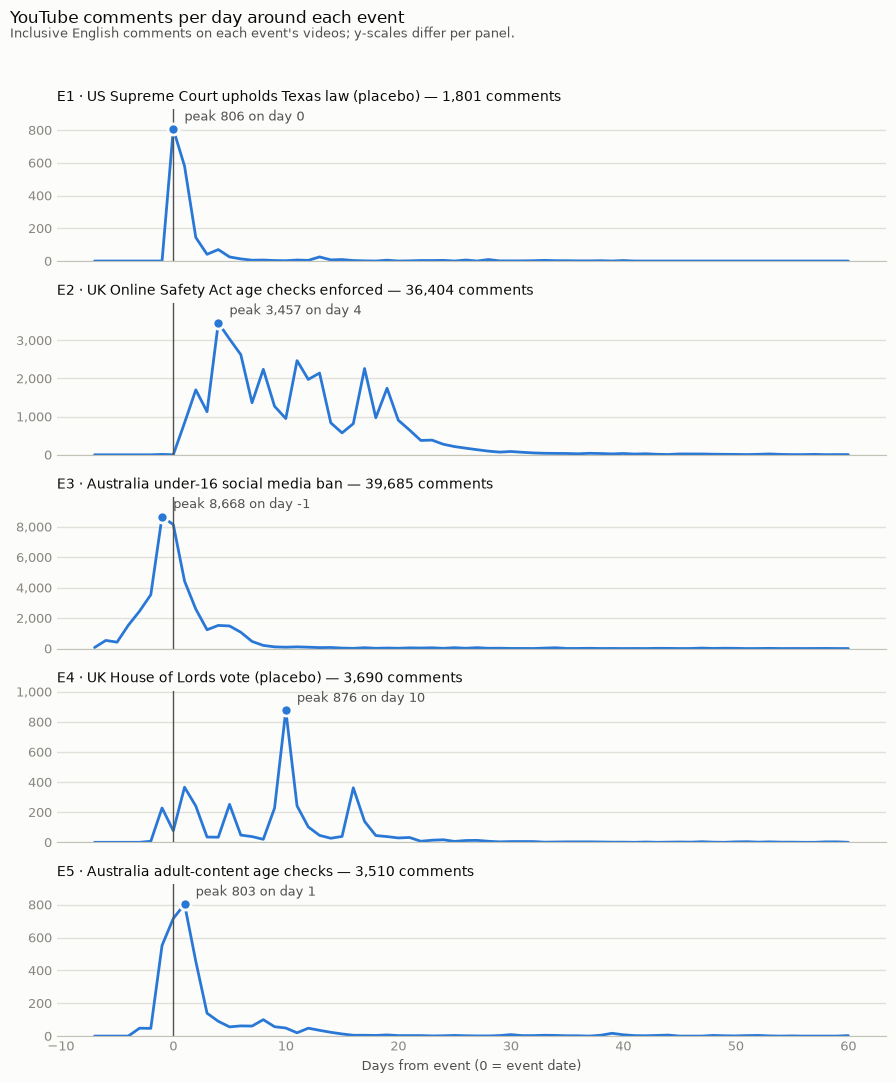

In [7]:
curve = summary.reaction_curve(documents)
figure = summary.plot_reaction_curves(curve)

Table view of the same data (comments per day from the event, inclusive English mask):

In [8]:
curve

yt_video_event_id,E1,E2,E3,E4,E5
yt_days_from_video_event,,,,,
-7,0,0,70,0,0
-6,0,0,533,0,0
-5,0,0,419,0,0
-4,0,0,1529,0,0
-3,0,0,2458,0,48
...,...,...,...,...,...
56,0,5,3,0,0
57,0,11,5,0,0
58,0,3,9,3,0


**Result.** E1 is a one-day spike (peak 806 on the ruling day; 93% of in-range comments fall in days 0–6). E2 builds after enforcement and stays high for about three weeks (peak 3,457 on day 4; only 35% in the first week). E3 peaks the day before the ban takes effect (8,668 on day −1) with 17,216 comments before day 0, i.e. anticipation coverage. E4 peaks ten days after the Lords vote (876 on day 10). E5 is short and sharp (803 on day 1; 66% in the first week).

**Why.** Shows whether discourse on each event's videos is concentrated around the event date, and how quickly it decays — context for the lead-lag analysis.

**Caveat.** Video publish dates cluster just after each event, so this curve mixes event salience with upload timing; it is not a population-level discourse series.

**Interpretation (Kien):** _…_

## 5. Bypass vocabulary

In [9]:
summary.bypass_by_event(documents)

,comments,with_bypass_terms,share,top_terms
yt_video_event_id,,,,
E1,1865,169,0.091,"vpn, use a vpn, get around, bypass, fake id"
E2,37907,2269,0.060,"vpn, bypass, use a vpn, get around, fake id"
E3,40100,956,0.024,"vpn, get around, bypass, use a vpn, proxy"
E4,3793,347,0.091,"vpn, use a vpn, get around, dns, bypass"
E5,3556,265,0.075,"vpn, bypass, get around, use a vpn, dns"


**Result.** Share of inclusive English comments mentioning a bypass term: E1 9.1%, E4 9.1%, E5 7.5%, E2 6.0%, E3 2.4%. "vpn" is the top term for every event, followed by "use a vpn", "bypass" and "get around".

**Why.** Input for the bypass-knowledge diffusion analysis (5.4b).

**Caveat.** Keyword matching is a weak pre-tag: "vpn" can appear in jokes or in arguments against the policy; it is not a frame label.

**Interpretation (Kien):** _…_

## 6. Network readiness

In [10]:
manifests = summary.load_manifests(PROCESSED)
pd.Series(manifests["edges"]["counts"]).to_frame("value")

,value
author_video_rows,64230
authors,56120
authors_on_2plus_videos,5645
reply_edges,38289
self_loops,1732
target_resolution,"{'handle_match': 9671, 'thread_root': 28618}"


In [11]:
summary.network_readiness(manifests)

,directed_pairs,handle_match_share,largest_component_share,nodes,reciprocity,reply_edges,self_loops,weak_components
yt_video_event_id,,,,,,,,
E1,940,0.2369,0.8497,672,0.1213,1127,38,38
E2,13856,0.2296,0.8758,10561,0.1020,15908,659,573
E3,14417,0.2759,0.8714,9901,0.1421,18384,883,537
E4,1265,0.1960,0.7230,1119,0.1186,1597,104,103
E5,1040,0.2883,0.8639,808,0.1481,1273,48,50


**Result.** 38,289 directed reply edges (25% resolved from a leading @handle, 1,732 self-loops); 56,120 users; 5,645 users commented on two or more videos, enabling audience-overlap projections. Reciprocity 0.10–0.15 and the largest weak component holds 72–88% of users per event.

**Why.** Confirms the reply graph is large and connected enough for community detection and centrality in Section 5.4, and the bipartite table supports channel-type bridges.

**Caveat.** Replies that don't tag anyone are attributed to the thread's top-level author; this is a heuristic.

**Interpretation (Kien):** _…_

## 7. Numbers for the report

In [12]:
prepare_counts = manifests["prepare"]["counts"]
pd.Series({
    "rows": prepare_counts["rows"],
    "videos / comments / replies": prepare_counts["by_thing"],
    "exclusion status": prepare_counts["by_exclusion_status"],
    "reply edges": manifests["edges"]["counts"]["reply_edges"],
    "users": manifests["edges"]["counts"]["authors"],
}).to_frame("value")

,value
rows,93728
videos / comments / replies,"{'comment': 55305, 'reply': 38289, 'video': 134}"
exclusion status,"{'bot_or_owner': 382, 'duplicate': 782, 'eligible': 52679, 'empty': 123, 'language_uncertain': 39658, 'non_english':..."
reply edges,38289
users,56120


## 8. Limitations
Full list with numbers: `docs/youtube/report_notes.md` §7. Key ones: no user location (jurisdiction is a hint from the video's event); search ranking favours popular videos; thin E5 arm; comments accumulate for months; language detection is uncertain on short comments; reply targets inferred from @handles; YouTube commenters are not a representative public.